![Teste vocacional com Machine Learning](capa.png)

# Projeto - Teste Vocacional com Machine Learning
## Etapa 03 - Análise Exploratória dos Dados (EDA)

Nesta etapa, os dados tratados são explorados para entender **como os perfis RIASEC se relacionam com as áreas de formação**, antes de construir o modelo.

**Entrada:** `dados/Dados processados/dados_limpos.csv` (gerado pelo `02_limpeza.ipynb`)

**Perguntas que esta etapa responde:**
1. Como os participantes se distribuem entre as áreas de formação?
2. Como se distribuem os escores de cada dimensão RIASEC?
3. Qual é o perfil RIASEC médio de cada área?
4. As dimensões RIASEC estão relacionadas entre si?
5. As áreas são distinguíveis pelos escores, ou há muita sobreposição?
6. Os perfis mudam entre homens e mulheres da mesma área?

In [5]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python usada neste Projeto:', python_version())

Versão da Linguagem Python usada neste Projeto: 3.14.4


In [6]:
# Os pacotes deste projeto estão listados no requirements.txt, na raiz do projeto.
# Para instalar, no terminal do VS Code, com o ambiente virtual ativado:
#
#   .venv\Scripts\Activate.ps1
#   pip install -r requirements.txt
#
# Depois de instalar ou atualizar um pacote, reinicie o kernel do notebook.

### Importando as bibliotecas necessárias

In [7]:
# Para manipulação dos dados - a dupla inseparável
import pandas as pd
import numpy as np

# Para visualização dos dados
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Gustavo" --iversions

Author: Gustavo

matplotlib: 3.11.2
numpy     : 2.5.3
pandas    : 3.0.6
platform  : 1.0.9
seaborn   : 0.13.2



### Importação do conjunto de dados tratado

In [9]:
# Importando o dataset tratado na etapa de limpeza (separado por vírgula, o padrão do to_csv)
df = pd.read_csv('../dados/Dados processados/dados_limpos.csv')

# Formato do dataset: devem ser 81.692 participantes e 101 colunas
df.shape

(81692, 101)

In [10]:
# As 6 dimensões do modelo de Holland e as colunas de escore correspondentes
dimensoes = {
    'R': 'Realista',
    'I': 'Investigativo',
    'A': 'Artístico',
    'S': 'Social',
    'E': 'Empreendedor',
    'C': 'Convencional',
}
colunas_escores = [f'escore_{letra}' for letra in dimensoes]

# Primeiras linhas, apenas com as colunas que interessam nesta etapa
df[['curso', 'area'] + colunas_escores].head()

,curso,area,escore_R,escore_I,escore_A,escore_S,escore_E,escore_C
0,Nursing,Saúde e bem-estar,1.750,4.375,2.375,2.750,1.250,1.250
1,education,Educação,1.625,4.500,4.250,4.625,2.500,3.250
2,Literature,Artes e humanidades,3.125,4.000,4.625,4.250,1.625,2.125
3,Math,"Ciências naturais, matemática e estatística",2.250,2.750,2.625,2.500,2.000,2.625
4,mathematics and science,"Ciências naturais, matemática e estatística",2.000,4.000,3.250,3.875,3.125,2.500


---
## 1. Distribuição dos participantes por área

**Objetivo:** ver quantos participantes existem em cada área de formação. Isso mostra se a base está **balanceada** ou se algumas áreas dominam, o que afeta diretamente a modelagem.



In [11]:
# Quantidade de participantes por área
contagem_areas = df['area'].value_counts()

# Porcentagem de participantes por área (normalize=True devolve a proporção; * 100 vira porcentagem)
porcentagem_areas = (df['area'].value_counts(normalize=True) * 100).round(2)

# Juntando as duas numa tabela, lado a lado (axis=1)
distribuicao_areas = pd.concat([contagem_areas, porcentagem_areas], axis=1)
distribuicao_areas.columns = ['Participantes', 'Porcentagem (%)']
distribuicao_areas

,Participantes,Porcentagem (%)
area,,
"Ciências sociais, comunicação e informação",23378,28.62
"Negócios, administração e direito",16719,20.47
Artes e humanidades,11046,13.52
Saúde e bem-estar,9015,11.04
"Ciências naturais, matemática e estatística",7583,9.28
"Engenharia, produção e construção",7100,8.69
Computação e TIC,3323,4.07
Educação,3195,3.91
Serviços,192,0.24


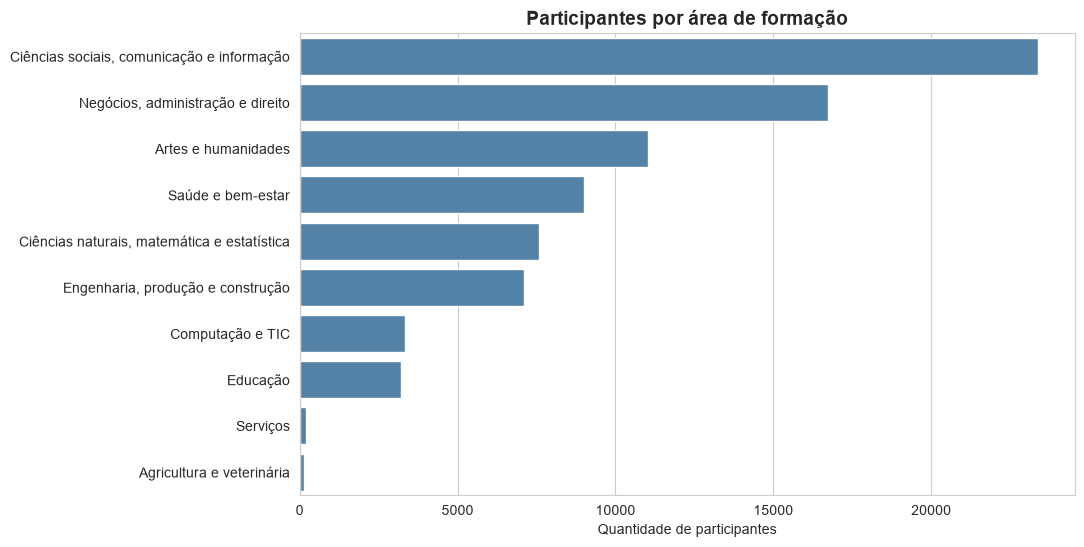

In [12]:
# Gráfico de barras horizontal, da maior para a menor área
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='area', order=contagem_areas.index, color='steelblue')
plt.title('Participantes por área de formação', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de participantes')
plt.ylabel('')
plt.show()


---
### Conclusões sobre a distribuição por área

A base é **desbalanceada**: Ciências sociais sozinha tem 28,6% dos participantes (muito puxada pela Psicologia), enquanto Serviços e Agricultura juntas não chegam a 0,5%.

**Linha de base (baseline):**
- Um modelo que sempre respondesse a maior área acertaria **28,62%** das vezes.
- Um modelo que sempre sugerisse as 3 maiores áreas acertaria **62,61%** no top-3.

Qualquer modelo construído precisa superar esses valores. O desbalanceamento também indica que a acurácia sozinha pode enganar: um modelo que só acerta as áreas grandes pode parecer bom. Por isso a avaliação também usará o **F1 macro**, que dá o mesmo peso a todas as áreas.


---
## 2. Distribuição dos escores RIASEC

**Objetivo:** entender como os escores de cada dimensão se distribuem entre todos os participantes. Quais dimensões têm escores mais altos em geral? Alguma é muito concentrada em valores baixos?



In [13]:
# Resumo estatístico dos 6 escores RIASEC
df[colunas_escores].describe().round(2)


,escore_R,escore_I,escore_A,escore_S,escore_E,escore_C
count,81692.00,81692.00,81692.00,81692.00,81692.00,81692.00
mean,2.10,3.03,2.94,3.39,2.59,2.44
std,0.88,1.03,1.00,0.88,0.88,0.98
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.38,2.25,2.14,2.88,1.88,1.62
50%,2.00,3.12,3.00,3.50,2.62,2.38
75%,2.75,3.88,3.75,4.00,3.25,3.12
max,5.00,5.00,5.00,5.00,5.00,5.00


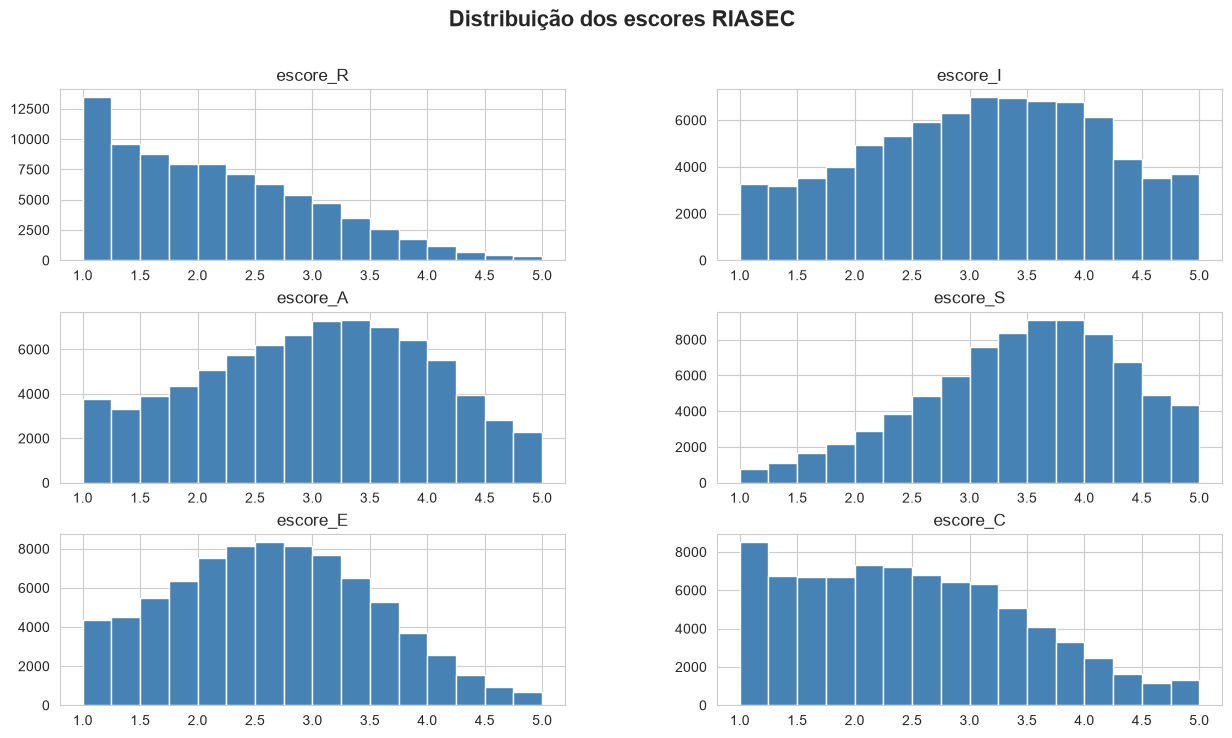

In [14]:
# Histograma de cada escore, direto pelo pandas (uma grade automática de gráficos)
df[colunas_escores].hist(bins=16, figsize=(15, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribuição dos escores RIASEC', fontsize=16, fontweight='bold')
plt.show()


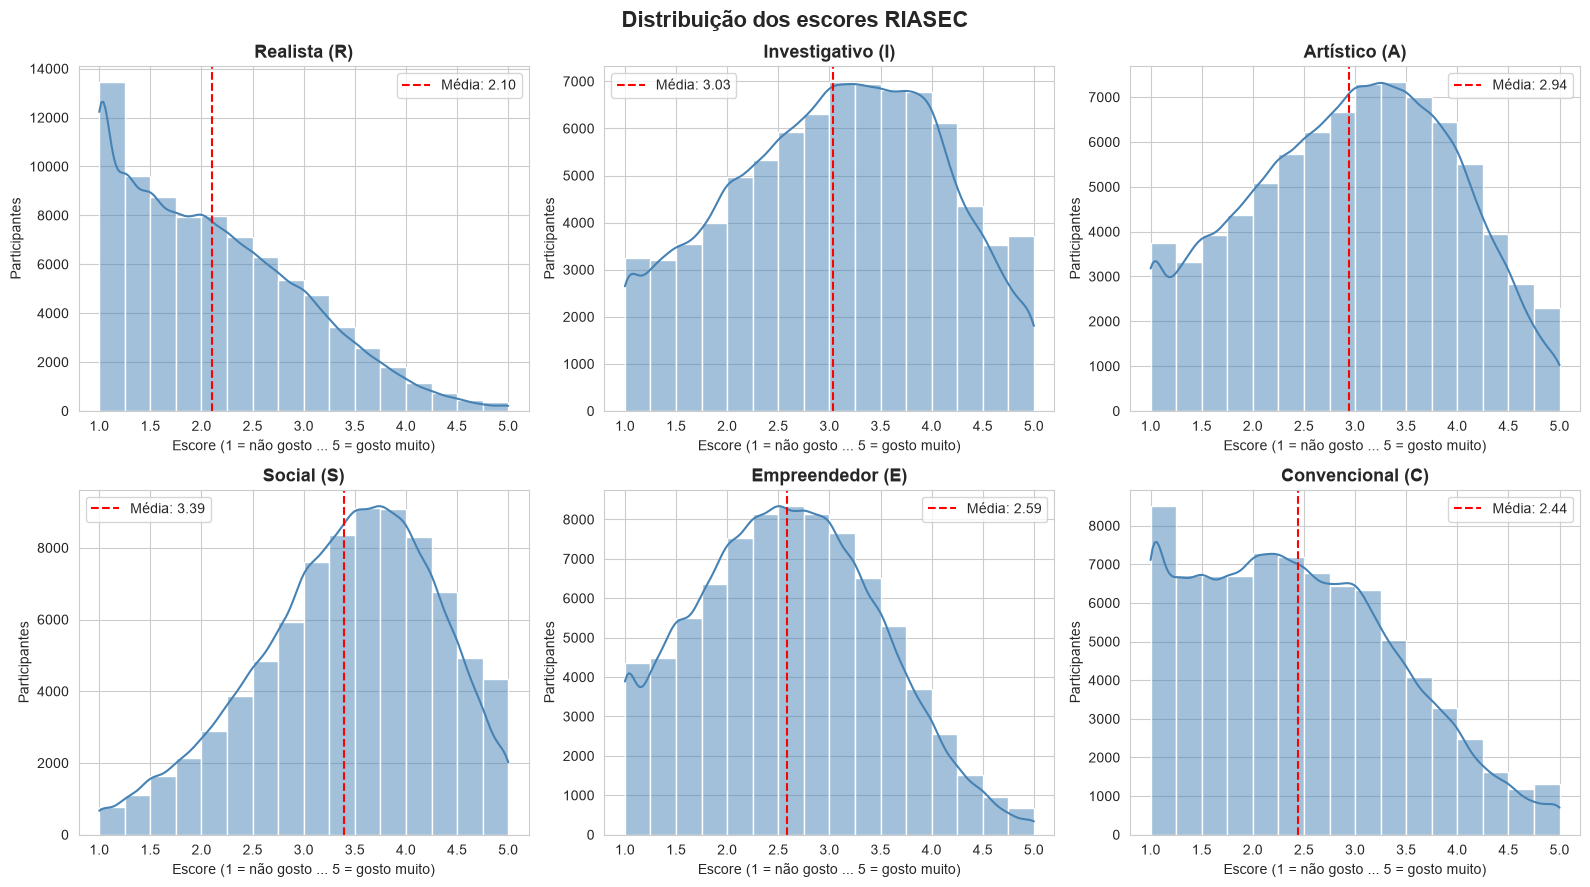

In [15]:
# Criando uma grade de 2 linhas x 3 colunas de gráficos
fig, eixos = plt.subplots(2, 3, figsize=(16, 9))

# Percorrendo as 6 dimensões e os 6 espaços da grade ao mesmo tempo
for (letra, nome), eixo in zip(dimensoes.items(), eixos.flatten()):
    coluna = f'escore_{letra}'

    # Histograma com a curva de densidade (KDE) por cima
    sns.histplot(data=df, x=coluna, binwidth=0.25, kde=True, color='steelblue', ax=eixo)

    # Linha vertical vermelha marcando a média
    media = df[coluna].mean()
    eixo.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')

    # Título e rótulos de cada gráfico
    eixo.set_title(f'{nome} ({letra})', fontsize=13, fontweight='bold')
    eixo.set_xlabel('Escore (1 = não gosto ... 5 = gosto muito)')
    eixo.set_ylabel('Participantes')
    eixo.legend()

# Fora do for: título geral, ajuste de espaços e exibição (uma vez só)
plt.suptitle('Distribuição dos escores RIASEC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Assimetria de cada escore: 0 = simétrico (sino), positivo = cauda à direita, negativo = cauda à esquerda
# Regra prática: entre -0,5 e 0,5 a distribuição é considerada aproximadamente simétrica
df[colunas_escores].skew().round(2)

escore_R    0.68
escore_I   -0.14
escore_A   -0.12
escore_S   -0.44
escore_E    0.18
escore_C    0.40
dtype: float64

---
### Conclusões sobre a distribuição dos escores

A linha vermelha em cada gráfico mostra a média do escore.

Os escores Investigativo, Artístico e Empreendedor têm distribuição aproximadamente normal, com assimetria próxima de zero.

O Realista é o mais assimétrico (0,68): a maioria dos participantes tem escores baixos, com acúmulo perto do mínimo (efeito piso), e uma cauda longa à direita. O Convencional segue o mesmo padrão, de forma mais suave (0,40).

O Social é o oposto (-0,44): a maioria tem escores altos, e a cauda se alonga para a esquerda. Quase todo mundo diz gostar de ajudar pessoas.

Isso é importante para o modelo: um escore Realista alto é raro, então é um sinal que diferencia bastante quem o tem. Já um Social alto é comum e diferencia menos.

---
## 3. Perfil RIASEC médio de cada área

**Objetivo:** calcular a média de cada escore por área. É a pergunta central do projeto: **cada área tem um perfil de interesses característico?**


In [17]:
# Média de cada escore RIASEC, separada por área de formação
perfil_areas = df.groupby('area')[colunas_escores].mean().round(2)
perfil_areas

,escore_R,escore_I,escore_A,escore_S,escore_E,escore_C
area,,,,,,
Agricultura e veterinária,2.51,3.53,2.76,3.10,2.41,2.48
Artes e humanidades,2.00,2.93,3.36,3.25,2.44,2.15
"Ciências naturais, matemática e estatística",2.22,3.67,2.85,3.19,2.36,2.45
"Ciências sociais, comunicação e informação",1.86,3.00,2.95,3.63,2.47,2.22
Computação e TIC,2.57,3.04,2.89,3.01,2.55,2.87
Educação,1.90,2.74,2.94,3.74,2.55,2.30
"Engenharia, produção e construção",2.86,3.11,2.91,3.09,2.69,2.74
"Negócios, administração e direito",2.17,2.72,2.87,3.30,3.01,2.84
Saúde e bem-estar,1.95,3.34,2.65,3.56,2.44,2.27


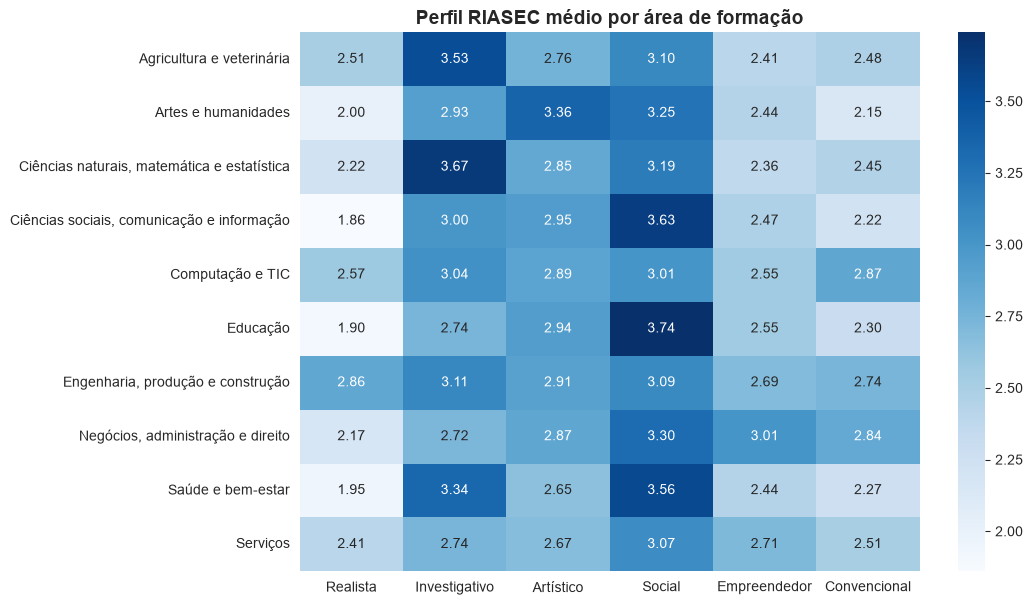

In [18]:
# Mapa de calor do perfil médio: quanto mais escura a cor, maior o escore
plt.figure(figsize=(10, 7))
sns.heatmap(perfil_areas, annot=True, fmt='.2f', cmap='Blues', xticklabels=list(dimensoes.values()))
plt.title('Perfil RIASEC médio por área de formação', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [19]:
# Média geral de cada escore (todos os participantes juntos)
media_geral = df[colunas_escores].mean()

# Diferença entre o perfil de cada área e a média geral
# Positivo = a área gosta MAIS dessa dimensão do que a média; negativo = gosta MENOS
desvio_areas = (perfil_areas - media_geral).round(2)
desvio_areas

,escore_R,escore_I,escore_A,escore_S,escore_E,escore_C
area,,,,,,
Agricultura e veterinária,0.41,0.50,-0.18,-0.29,-0.18,0.04
Artes e humanidades,-0.10,-0.10,0.42,-0.14,-0.15,-0.29
"Ciências naturais, matemática e estatística",0.12,0.64,-0.09,-0.20,-0.23,0.01
"Ciências sociais, comunicação e informação",-0.24,-0.03,0.01,0.24,-0.12,-0.22
Computação e TIC,0.47,0.01,-0.05,-0.38,-0.04,0.43
Educação,-0.20,-0.29,0.00,0.35,-0.04,-0.14
"Engenharia, produção e construção",0.76,0.08,-0.03,-0.30,0.10,0.30
"Negócios, administração e direito",0.07,-0.31,-0.07,-0.09,0.42,0.40
Saúde e bem-estar,-0.15,0.31,-0.29,0.17,-0.15,-0.17


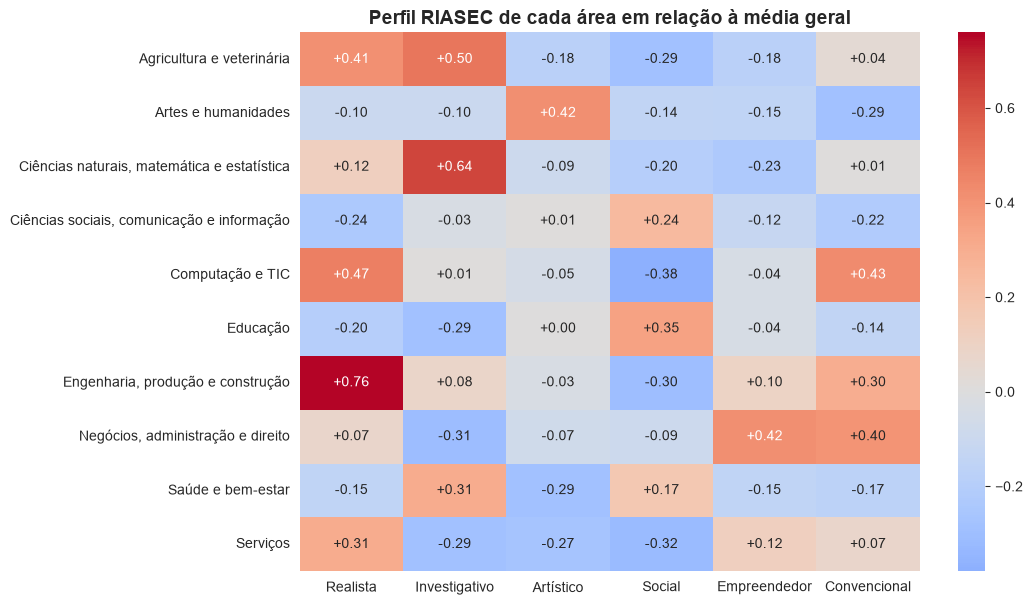

In [20]:
# Mapa de calor dos desvios: vermelho = acima da média geral, azul = abaixo
plt.figure(figsize=(10, 7))
sns.heatmap(desvio_areas, annot=True, fmt='+.2f', cmap='coolwarm', center=0,
            xticklabels=list(dimensoes.values()))
plt.title('Perfil RIASEC de cada área em relação à média geral', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.show()


---
### Conclusões sobre o perfil médio das áreas

No mapa das médias, o Social aparece alto em quase todas as áreas, porque quase todos os participantes têm Social alto. Por isso, a média sozinha não mostra o que diferencia as áreas.

O mapa de desvios em relação à média geral revela o que é característico de cada área:
- **Engenharia:** Realista (+0,76), o maior destaque do mapa
- **Computação:** Realista (+0,47) e Convencional (+0,43)
- **Negócios:** Empreendedor (+0,42) e Convencional (+0,40)
- **Artes:** Artístico (+0,42)
- **Ciências naturais:** Investigativo (+0,64)
- **Educação:** Social (+0,35)
- **Saúde:** Investigativo (+0,31) e Social (+0,17)

Os resultados confirmam a teoria de Holland: cada área se destaca justamente na dimensão que a teoria associa a ela.

As áreas Agricultura e Serviços têm poucos participantes (141 e 192), então as suas médias são menos confiáveis.

---
## 4. O perfil de cada área em gráfico de radar

**Objetivo:** visualizar o perfil RIASEC de cada área como um **hexágono**, uma "impressão digital" de interesses. É o gráfico mais característico de testes vocacionais, e o que vai aparecer na tela de resultado do site.



In [21]:
def grafico_radar(areas, titulo='Perfil RIASEC médio por área'):
    # Ângulos das 6 dimensões, com o primeiro repetido para fechar o hexágono
    angulos = np.linspace(0, 2 * np.pi, len(dimensoes), endpoint=False).tolist()
    angulos_fechados = angulos + angulos[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

    # Um hexágono para cada área da lista
    for area in areas:
        valores = perfil_areas.loc[area].tolist()
        valores_fechados = valores + valores[:1]
        ax.plot(angulos_fechados, valores_fechados, linewidth=2, label=area)
        ax.fill(angulos_fechados, valores_fechados, alpha=0.15)

    ax.set_xticks(angulos)
    ax.set_xticklabels(list(dimensoes.values()), fontsize=11)
    ax.set_ylim(1, 5)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)

    # Legenda fora do círculo, para não cobrir o gráfico
    ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1))
    plt.show()


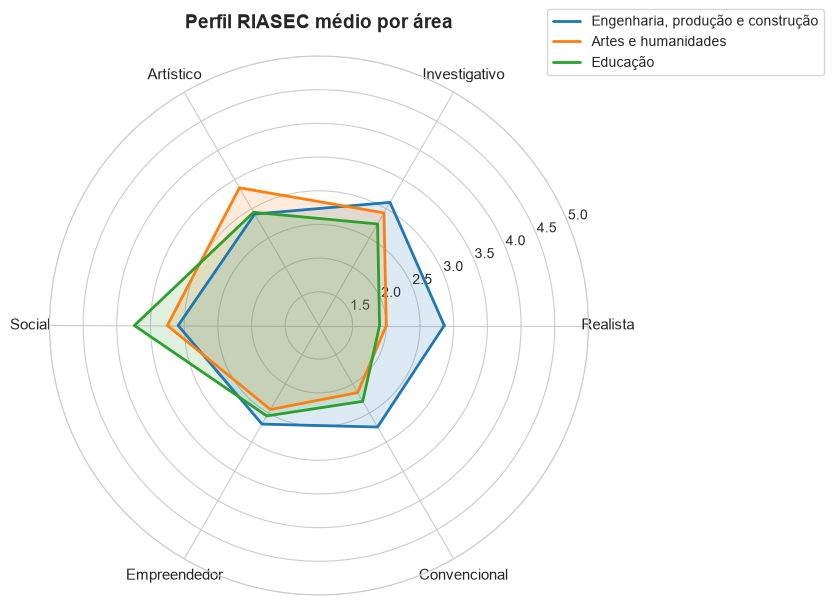

In [22]:
# Comparando três áreas com perfis bem diferentes
grafico_radar(['Engenharia, produção e construção', 'Artes e humanidades', 'Educação'])


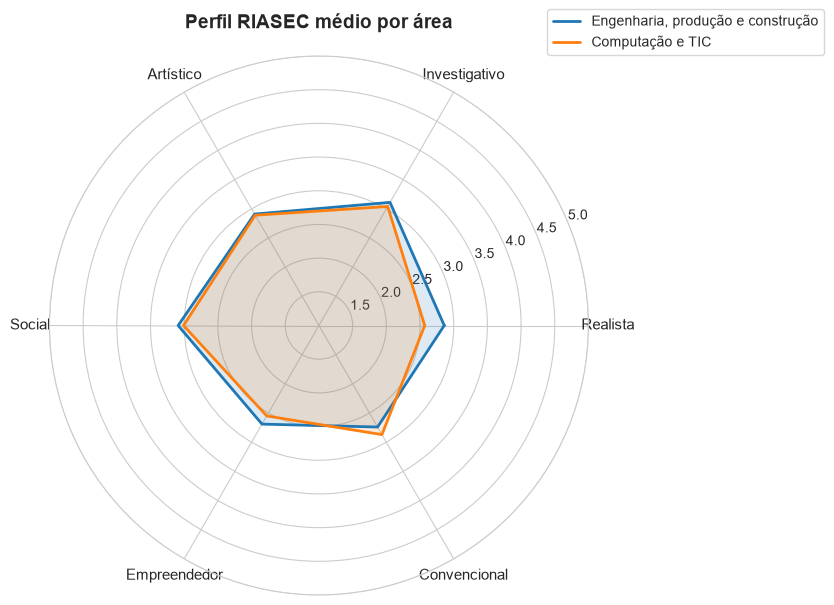

In [23]:
# Pares com perfis parecidos, que o modelo pode confundir
grafico_radar(['Engenharia, produção e construção', 'Computação e TIC'])

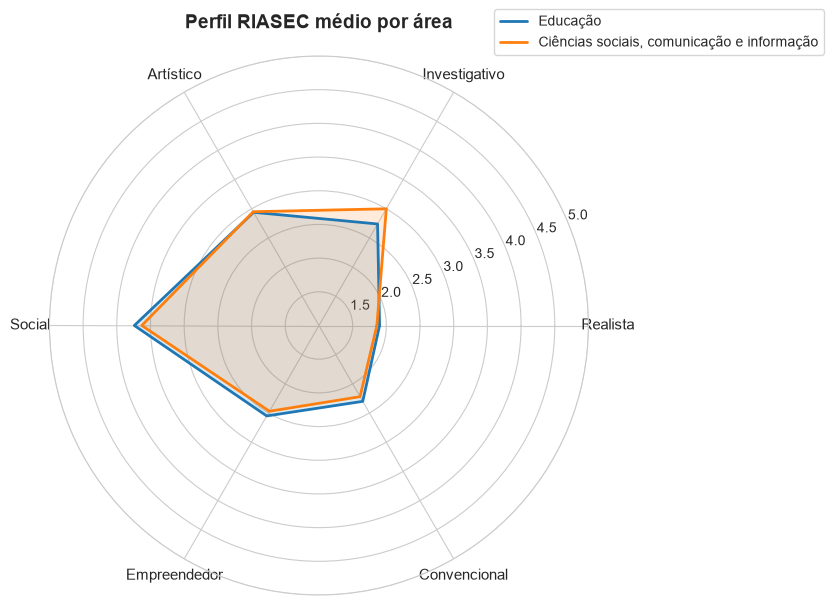

In [24]:
grafico_radar(['Educação', 'Ciências sociais, comunicação e informação'])

---
### Conclusões sobre os gráficos de radar

Os radares confirmam os perfis característicos: Engenharia se destaca no Realista, Artes no Artístico e Educação no Social.

Porém, alguns pares de áreas têm perfis médios quase idênticos:
- **Engenharia e Computação** (diferença máxima de 0,29, no Realista)
- **Educação e Ciências sociais** (diferença máxima de 0,26, no Investigativo)

Esses pares provavelmente serão confundidos pelo modelo. A recomendação das 3 áreas mais compatíveis reduz esse problema, porque áreas com interesses próximos tendem a aparecer juntas no resultado.

Como o radar usa a escala completa do teste (1 a 5), diferenças pequenas ficam pouco visíveis. Para comparar áreas parecidas, o mapa de desvios da seção 3 é mais sensível.

---
## 5. Correlação entre as dimensões RIASEC

**Objetivo:** verificar se as dimensões são independentes ou se andam juntas. Segundo a teoria de Holland, as dimensões vizinhas no hexágono (ex.: R e I, S e E) tendem a estar mais relacionadas do que as opostas (ex.: R e S).


In [25]:
#Correlação entre os 6 scores RIASEC (CADA PAR DE DIMENSÕES)
correlacao = df[colunas_escores].corr().round(2)
correlacao

,escore_R,escore_I,escore_A,escore_S,escore_E,escore_C
escore_R,1.00,0.32,0.20,0.07,0.32,0.48
escore_I,0.32,1.00,0.32,0.18,0.03,0.08
escore_A,0.20,0.32,1.00,0.30,0.28,-0.00
escore_S,0.07,0.18,0.30,1.00,0.36,0.15
escore_E,0.32,0.03,0.28,0.36,1.00,0.50
escore_C,0.48,0.08,-0.00,0.15,0.50,1.00


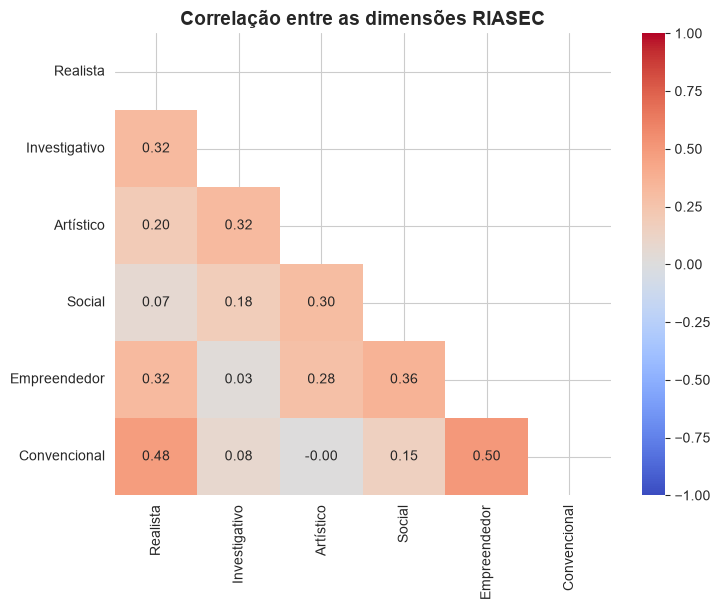

In [26]:
# Nomes das dimensões para os eixos do gráfico
nomes_dimensoes = list(dimensoes.values())

# Máscara para esconder a metade de cima (repetida) e a diagonal (sempre 1)
mascara = np.triu(np.ones_like(correlacao, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            xticklabels=nomes_dimensoes, yticklabels=nomes_dimensoes)
plt.title('Correlação entre as dimensões RIASEC', fontsize=14, fontweight='bold')
plt.show()


In [27]:
# Pares de dimensões agrupados pela distância entre elas no hexágono R-I-A-S-E-C
pares = {
    'Vizinhas (lado a lado)':  [('R', 'I'), ('I', 'A'), ('A', 'S'), ('S', 'E'), ('E', 'C'), ('C', 'R')],
    'Alternadas (uma entre)':  [('R', 'A'), ('I', 'S'), ('A', 'E'), ('S', 'C'), ('E', 'R'), ('C', 'I')],
    'Opostas (frente a frente)': [('R', 'S'), ('I', 'E'), ('A', 'C')],
}

# Média da correlação em cada grupo de pares
for grupo, lista_pares in pares.items():
    valores = [correlacao.loc[f'escore_{a}', f'escore_{b}'] for a, b in lista_pares]
    print(f'{grupo:28} média = {np.mean(valores):.2f}   {valores}')


Vizinhas (lado a lado)       média = 0.38   [np.float64(0.32), np.float64(0.32), np.float64(0.3), np.float64(0.36), np.float64(0.5), np.float64(0.48)]
Alternadas (uma entre)       média = 0.20   [np.float64(0.2), np.float64(0.18), np.float64(0.28), np.float64(0.15), np.float64(0.32), np.float64(0.08)]
Opostas (frente a frente)    média = 0.03   [np.float64(0.07), np.float64(0.03), np.float64(-0.0)]


---
### Conclusões sobre a correlação entre as dimensões

O par mais forte é Empreendedor e Convencional (0,50), ligado ao perfil da área de Negócios.

O teste do hexágono confirma a teoria de Holland: dimensões vizinhas têm correlação média de 0,38, alternadas de 0,20 e opostas de 0,03.

Nenhum par passa de 0,8, então não há multicolinearidade forte: as 6 dimensões trazem informações diferentes e todas serão usadas no modelo.

---
## 6. As áreas são distinguíveis?

**Objetivo:** a média mostra o perfil "típico" de cada área, mas esconde a **variação** entre as pessoas. Se os escores de duas áreas se sobrepõem muito, o modelo vai ter dificuldade de separá-las.

 **Para pensar:** em qual dimensão as caixas das áreas ficam mais separadas? Quais pares de áreas parecem quase iguais? Anote: provavelmente são as áreas que o modelo mais vai confundir.

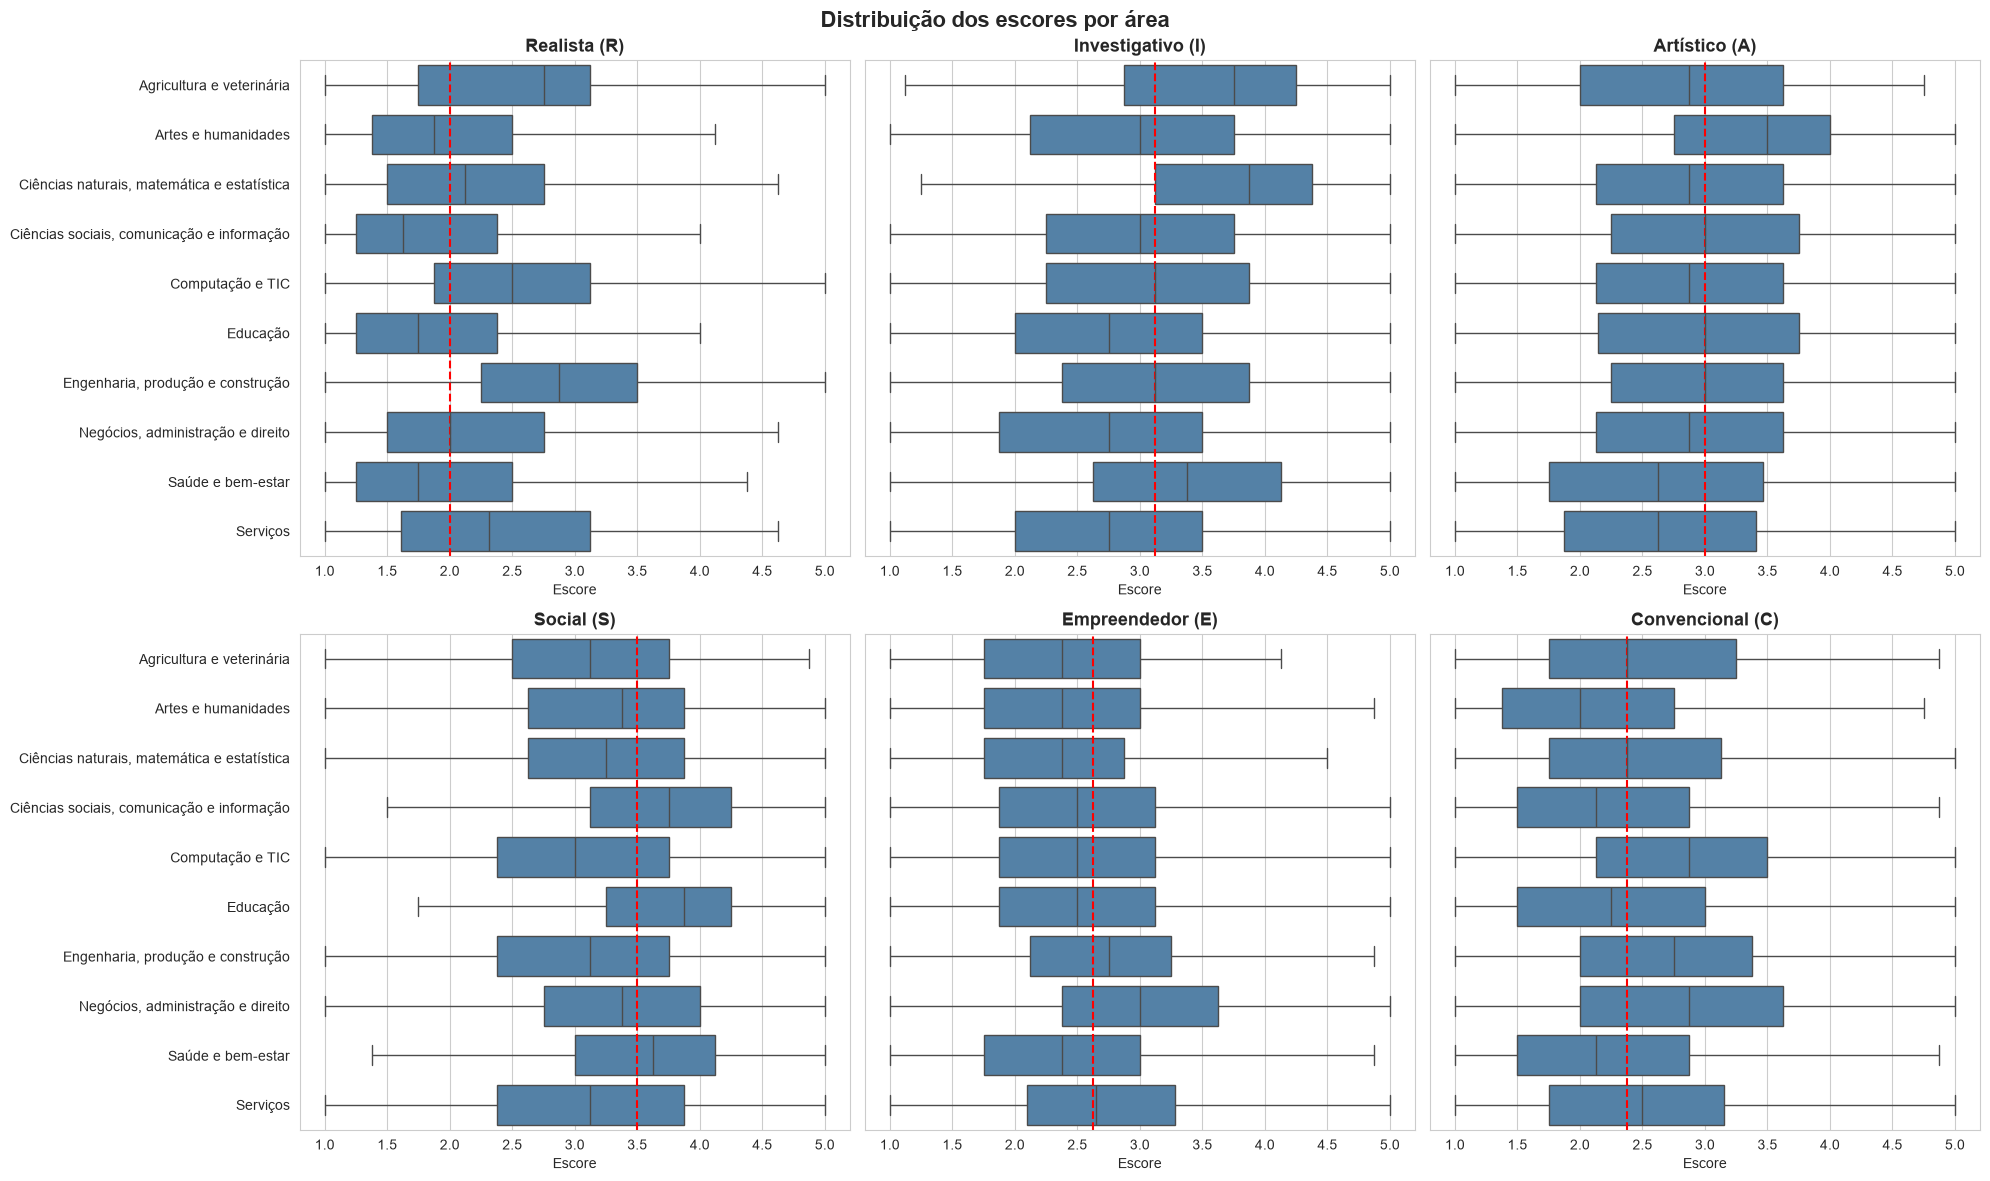

In [31]:
# Grade de 2 linhas x 3 colunas; sharey=True usa os mesmos nomes de área no eixo Y de todos os gráficos
fig, eixos = plt.subplots(2, 3, figsize=(20, 12), sharey=True)

# Áreas em ordem alfabética, para ficarem na mesma posição em todos os gráficos
ordem_areas = sorted(df['area'].unique())

for (letra, nome), eixo in zip(dimensoes.items(), eixos.flatten()):
    coluna = f'escore_{letra}'

    # Um boxplot por área (showfliers=False esconde os pontos extremos, para o gráfico ficar limpo)
    sns.boxplot(data=df, x=coluna, y='area', order=ordem_areas,
                color='steelblue', showfliers=False, ax=eixo)

    # Linha vermelha: mediana geral, para comparar cada área com o participante típico
    eixo.axvline(df[coluna].median(), color='red', linestyle='--')

    eixo.set_title(f'{nome} ({letra})', fontsize=13, fontweight='bold')
    eixo.set_xlabel('Escore')
    eixo.set_ylabel('')

plt.suptitle('Distribuição dos escores por área', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


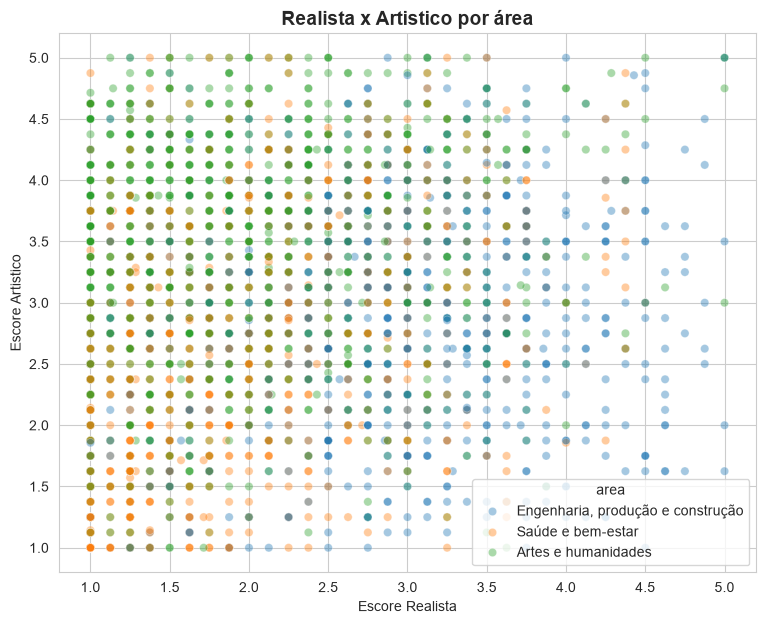

In [36]:
#tres areas de perfis bem diferentes 
areas_comparadas = ['Engenharia, produção e construção', 'Artes e humanidades', 'Saúde e bem-estar']

#Amostra de 3.000 participantes dessas áreas 

amostra_areas = df[df['area'].isin(areas_comparadas)].sample(3000, random_state=42)

plt.figure(figsize=(9, 7))
sns.scatterplot(data=amostra_areas, x='escore_R', y='escore_A', hue='area', alpha=0.4)
plt.title('Realista x Artistico por área', fontsize=14, fontweight='bold')
plt.xlabel('Escore Realista')
plt.ylabel('Escore Artistico')
plt.show()
               

---
### Conclusões sobre a separação das áreas

Os boxplots mostram que as medianas das áreas são diferentes, confirmando os perfis da seção 3. A dimensão que mais separa as áreas é o Realista: a mediana de Engenharia (2,88) fica bem acima da de Ciências sociais (1,62). No Artístico e no Empreendedor, as caixas ficam quase alinhadas, e só uma área se destaca em cada uma (Artes e Negócios).

Mesmo assim, as caixas se sobrepõem bastante em todas as dimensões. Pessoas de áreas diferentes muitas vezes têm escores parecidos.

O gráfico de dispersão (Realista x Artístico) mostra o mesmo: nas extremidades as áreas se separam (Realista alto é quase só Engenharia, Artístico alto com Realista baixo é mais Artes), mas no meio, onde está a maioria das pessoas, as três áreas se misturam.

**O que isso significa para o modelo:**
- Uma dimensão sozinha separa pouco. O modelo precisa usar as 6 dimensões juntas.
- Com tanta sobreposição, não é realista esperar um acerto muito alto no top-1. O objetivo é superar com folga as linhas de base (28,62% no top-1 e 62,61% no top-3).
- Isso reforça a escolha de recomendar as 3 áreas mais compatíveis, em vez de uma só.

---
## 7. Perfis por gênero dentro de cada área

**Objetivo:** investigar o risco de viés identificado na limpeza. Dentro da **mesma área**, homens e mulheres têm perfis diferentes?

**Para pensar:** se uma área é 80% feminina, o modelo pode aprender "perfil feminino → essa área". É por isso que o `genero` não entra no modelo, mas o viés pode entrar **indiretamente** pelos escores. Como poderíamos verificar isso na avaliação?

In [37]:
# Mantendo só masculino (1) e feminino (2): os códigos 3 (outro, 444 pessoas) e 0 (não respondeu, 94) têm poucos casos
df_genero = df[df['genero'].isin([1, 2])].copy()

#trocando os códigos por nomes para as tabels e graficos ficarem legiveis
df_genero['genero'] = df_genero['genero'].map({1: 'Masculino', 2: 'Feminino'})

#Proporção de cada genero na base 
df_genero['genero'].value_counts(normalize=True).round(3)

genero
Feminino     0.677
Masculino    0.323
Name: proportion, dtype: float64

In [39]:
# Tabela cruzada linha = área, colunas = gênero
# normalize='index' faz cada LINHA somar 100 por cento a proporção de cada área
genero_por_area = (pd.crosstab(df_genero['area'], df_genero['genero'], normalize='index') * 100).round(1)

# Ordenando da área menos feminina para a mais feminina
genero_por_area = genero_por_area.sort_values('Feminino', ascending=True)
genero_por_area

genero,Feminino,Masculino
area,,
Computação e TIC,34.9,65.1
"Engenharia, produção e construção",36.7,63.3
Serviços,50.5,49.5
Agricultura e veterinária,55.1,44.9
"Negócios, administração e direito",63.1,36.9
"Ciências naturais, matemática e estatística",64.6,35.4
Artes e humanidades,70.0,30.0
"Ciências sociais, comunicação e informação",78.2,21.8
Saúde e bem-estar,80.1,19.9


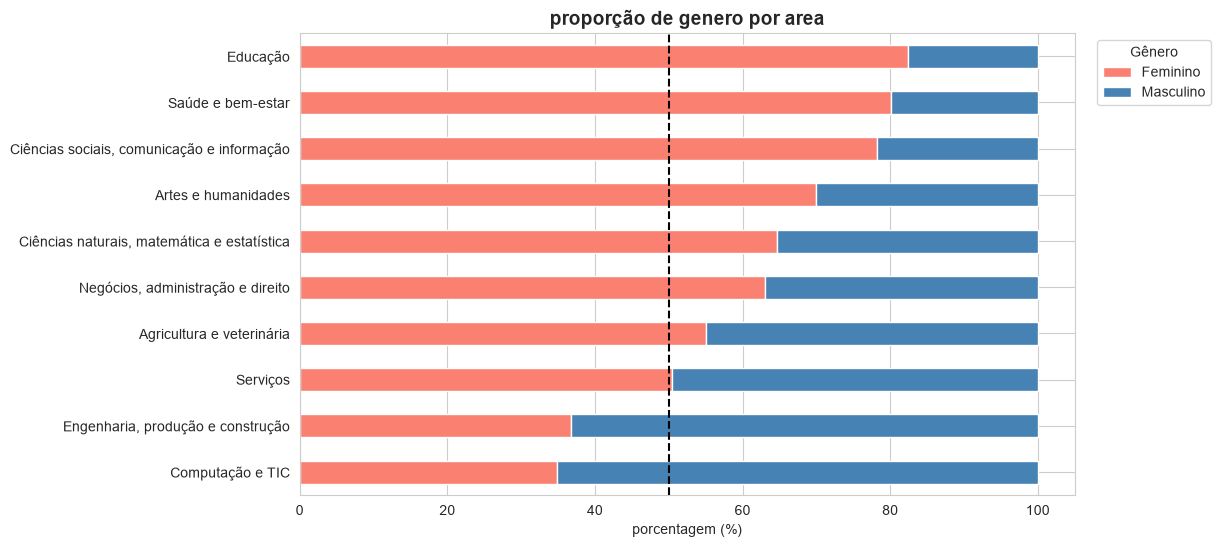

In [42]:
#barras empilhadas  cada barra uma área 
genero_por_area.plot(kind='barh', stacked=True, figsize=(10, 6), color=['salmon', 'steelblue'])
# linha preta 50%
plt.axvline(50, color='black', linestyle='--')
plt.title('proporção de genero por area', fontsize=14, fontweight='bold')
plt.xlabel('porcentagem (%)')
plt.ylabel('')
plt.legend(title='Gênero', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

---
### Conclusões sobre gênero por área

A base tem 67,7% de mulheres e 32,3% de homens. Por isso, uma área sem preferência de gênero ficaria perto de 68% de mulheres, e não de 50%.

- **Bem acima da média da base:** Educação (82,4%), Saúde (80,1%) e Ciências sociais (78,2%)
- **Perto da média da base:** Artes (70,0%), Ciências naturais (64,6%) e Negócios (63,1%)
- **Bem abaixo da média da base:** Engenharia (36,7%) e Computação (34,9%)

Serviços e Agricultura têm poucos participantes, então as suas proporções são pouco confiáveis.

**Risco de viés:** a coluna `genero` não vai entrar no modelo, mas o viés pode entrar de forma indireta pelos escores. Na limpeza, vimos que as mulheres marcam mais "não gosto" nas perguntas do Realista, e o Realista é o principal sinal de Engenharia e Computação. Assim, o modelo pode recomendar essas áreas com menos frequência para mulheres com interesses parecidos aos dos homens que as cursam.

**Como verificar na avaliação:** calcular a acurácia top-3 separadamente para homens e mulheres e comparar, principalmente nas áreas de Engenharia e Computação.

---
## Conclusões da análise exploratória

> ✏️ Escreva aqui, com as suas palavras, o que cada análise revelou e o que isso significa para a modelagem. Algumas perguntas para guiar:
> - A base está balanceada? Qual é a acurácia de linha de base?
> - Quais áreas têm os perfis mais marcantes? Quais são mais parecidas entre si?
> - Os dados confirmam a teoria do hexágono de Holland?
> - O que foi observado sobre gênero?
> - O que deve ser levado em conta na etapa de modelagem?

## Fim da Etapa 03